# Chap 12 - Ex4: cluster customers into group using Wholesale_customers.csv

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

np.set_printoptions(suppress = True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
wholesale = pd.read_csv('Data/Wholesale_customers.csv')
wholesale

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [4]:
wholesale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB



------------------------ Channel ------------------------------


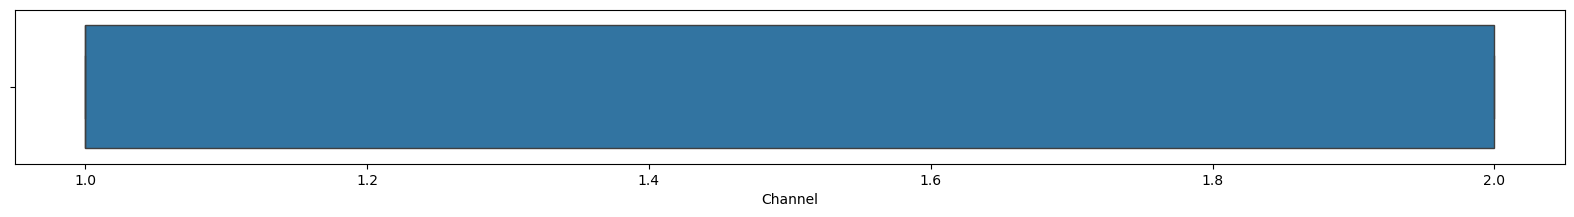


------------------------ Region ------------------------------


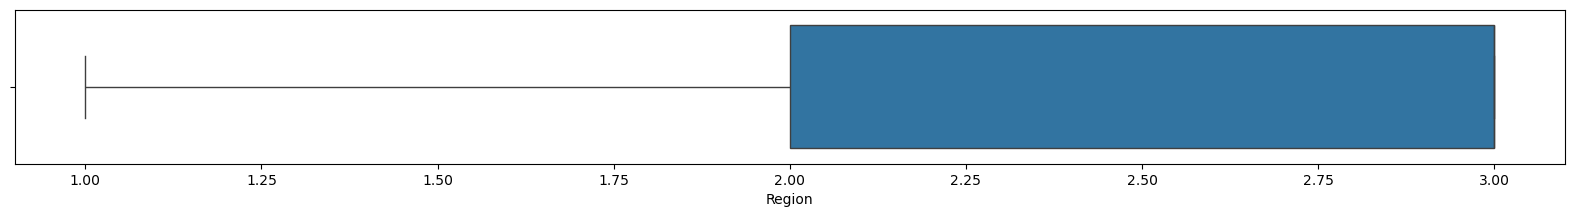


------------------------ Fresh ------------------------------


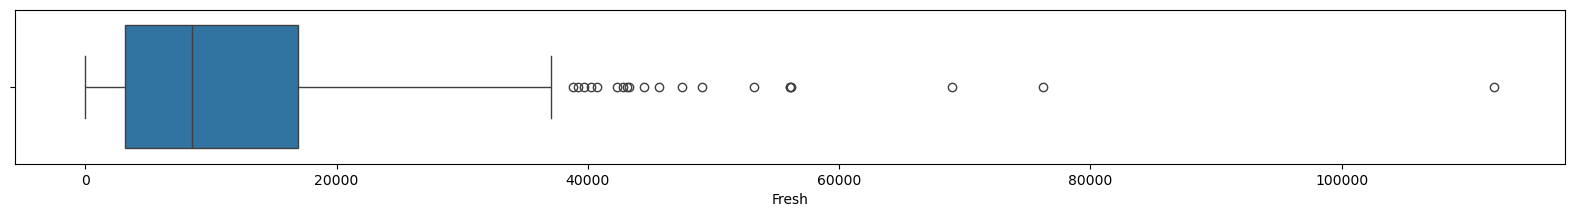


------------------------ Milk ------------------------------


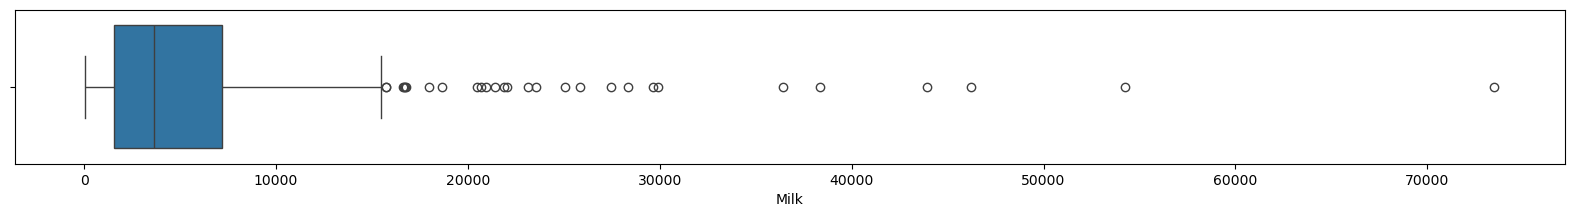


------------------------ Grocery ------------------------------


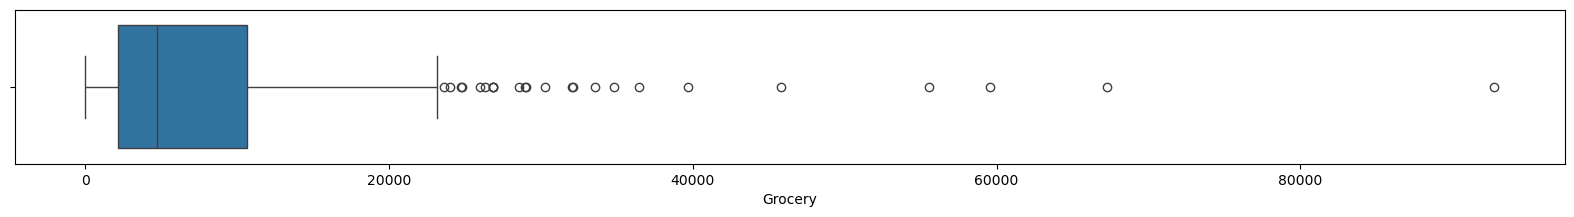


------------------------ Frozen ------------------------------


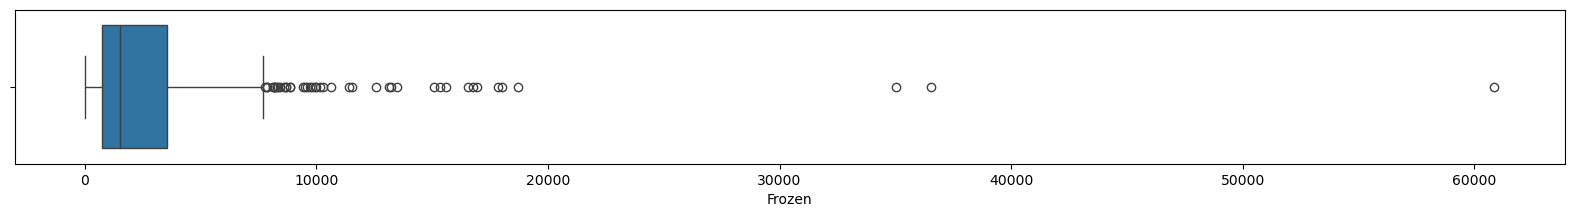


------------------------ Detergents_Paper ------------------------------


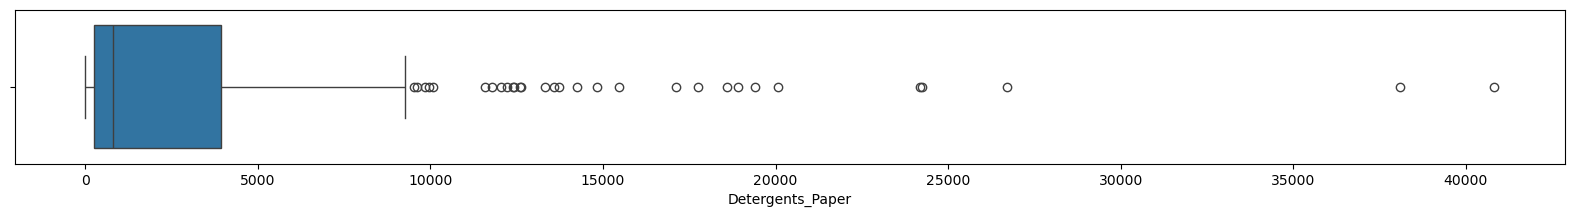


------------------------ Delicassen ------------------------------


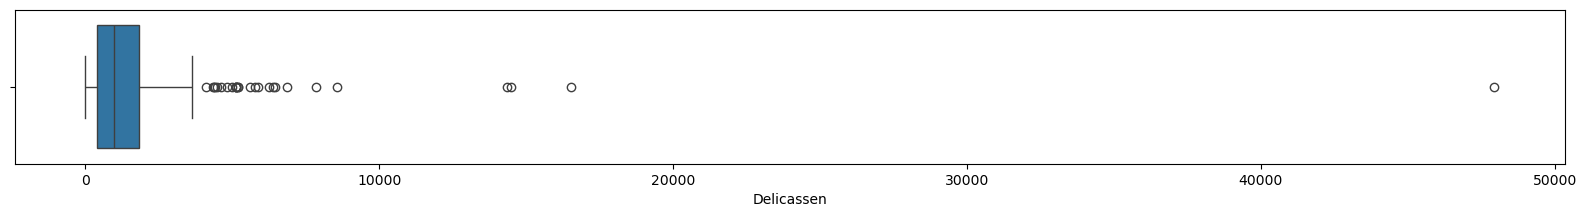

In [5]:
for col in wholesale.columns:
    print(f'\n------------------------ {col} ------------------------------')
    plt.figure(figsize = (20, 2))
    sbn.boxplot(data = wholesale, x = col)
    plt.show()

## Use RobustScaler because so many outliers
## or Use Natural Logarith scaling method since the data are very right-skewed

## <span style = 'color:yellow'> Find optimal K using Silhoutte Score

In [6]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
from imblearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer

k_nums = range(2, 16)

num_feats = wholesale.columns.to_list()
num_feats.remove('Channel')
num_feats.remove('Region')

for k in k_nums:
    data = wholesale.copy()
    hierclust_pipe = Pipeline([
        ('RobustScaler', make_column_transformer((RobustScaler(), num_feats), remainder = 'passthrough')),
        ('HierachichalClustering', AgglomerativeClustering(n_clusters = k))
    ])
    hierclust_pipe.fit(data)
    labels = hierclust_pipe.named_steps['HierachichalClustering'].labels_
    print(f'Silhouette score for k = {k}: {silhouette_score(data, labels)}')

print('\nChoose K = 2 clusters')

Silhouette score for k = 2: 0.725561860967824
Silhouette score for k = 3: 0.6894218332883774
Silhouette score for k = 4: 0.46688199214837245
Silhouette score for k = 5: 0.20705471193989772
Silhouette score for k = 6: 0.20756554368160648
Silhouette score for k = 7: 0.20539520828851596
Silhouette score for k = 8: 0.15676930025275032
Silhouette score for k = 9: 0.13970649086195788
Silhouette score for k = 10: 0.12419671578984265
Silhouette score for k = 11: 0.0008713685561897606
Silhouette score for k = 12: 0.038256971373769454
Silhouette score for k = 13: 0.03872850778212624
Silhouette score for k = 14: 0.03920236732165442
Silhouette score for k = 15: 0.0328681058807893

Choose K = 2 clusters


## <span style = 'color:yellow'> Build official model

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

def plot_clustered_heatmap(data, model, title="Clustered Heatmap"):
    """
    Plots a clustered heatmap from AgglomerativeClustering outputs.

    Args:
        data: The original data (DataFrame or NumPy array).
        model: Fitted AgglomerativeClustering model.
        title: Title of the plot.
    """

    # Create linkage matrix
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Reorder the data based on clustering
    if isinstance(data, pd.DataFrame):
        ordered_indices = model.labels_
        ordered_data = data.iloc[np.argsort(ordered_indices)]
    else:
        ordered_indices = model.labels_
        ordered_data = data[np.argsort(ordered_indices)]

    # Plot the clustered heatmap
    fig = sbn.clustermap(ordered_data, row_linkage=linkage_matrix, col_cluster=False, figsize=(10, 10), cmap="viridis", cbar_pos=(0.02, 0.8, 0.03, 0.15))
    fig.ax_heatmap.set_title(title)
    plt.show()

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

def plot_dendrogram(model, **kwargs):
    """
    Plots a dendrogram from an AgglomerativeClustering model.

    Args:
        model: AgglomerativeClustering model.
        **kwargs: Keyword arguments to pass to scipy.cluster.hierarchy.dendrogram.
    """
    # Create linkage matrix from the model's children.
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram.
    dendrogram(linkage_matrix, **kwargs)
    plt.show()

## Using RobustScaler 

     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Group
0          2       3  12669   9656     7561     214              2674        1338      0
1          2       3   7057   9810     9568    1762              3293        1776      0
2          2       3   6353   8808     7684    2405              3516        7844      0
3          1       3  13265   1196     4221    6404               507        1788      0
4          2       3  22615   5410     7198    3915              1777        5185      0
..       ...     ...    ...    ...      ...     ...               ...         ...    ...
435        1       3  29703  12051    16027   13135               182        2204      0
436        1       3  39228   1431      764    4510                93        2346      0
437        2       3  14531  15488    30243     437             14841        1867      0
438        1       3  10290   1981     2232    1038               168        2125      0
439        1       3 

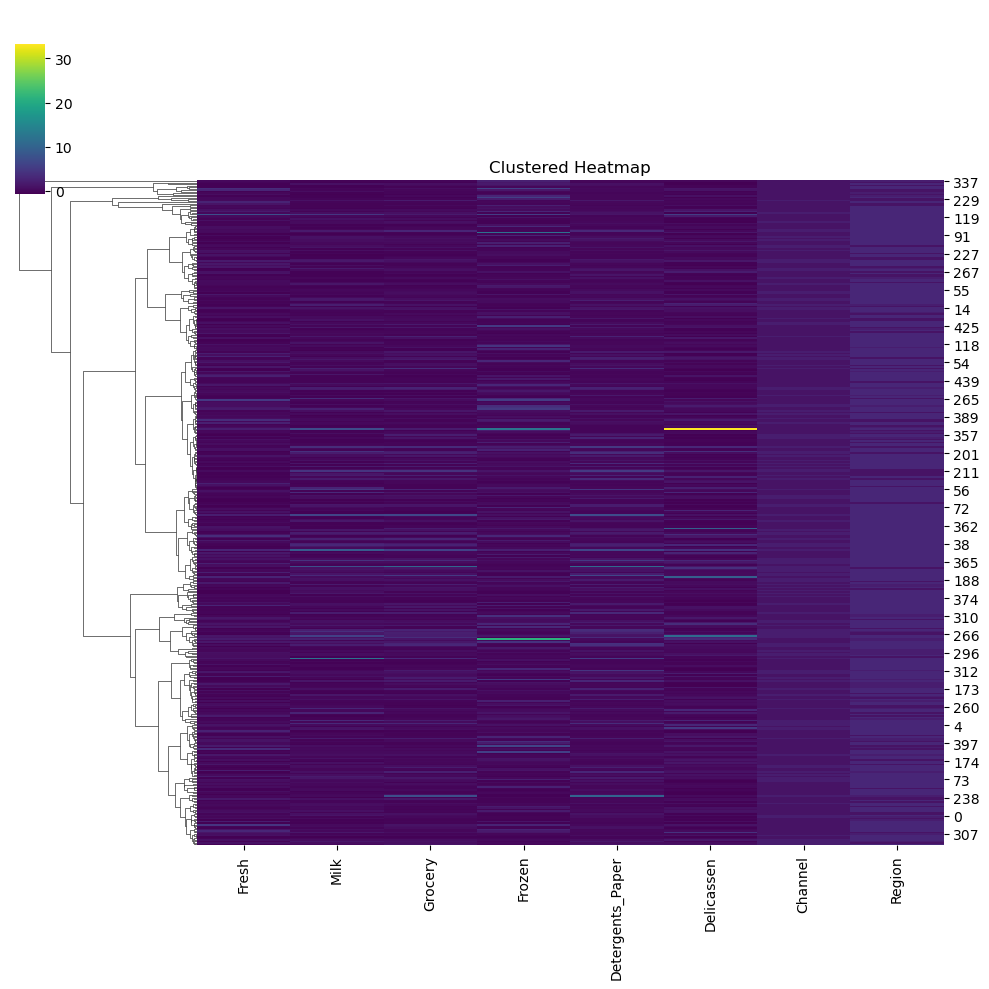

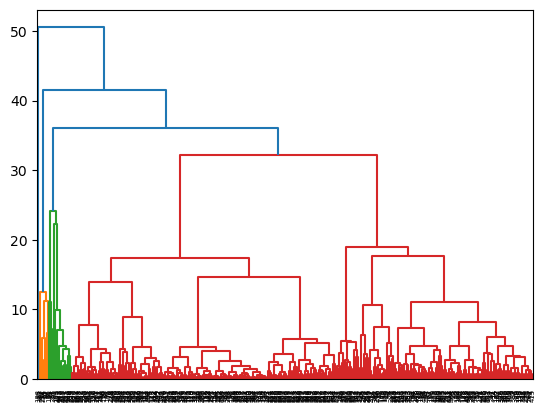

In [8]:
data = wholesale.copy()
hierclust_pipe = Pipeline([
        ('RobustScaler', make_column_transformer((RobustScaler(), num_feats), remainder = 'passthrough')),
        ('HierachichalClustering', AgglomerativeClustering(n_clusters = 2, compute_distances = True))
    ])
hierclust_pipe.fit(data)
labels = hierclust_pipe.named_steps['HierachichalClustering'].labels_

data['Group'] = labels
print(data)
print()

data_scaled_plot = hierclust_pipe.named_steps['RobustScaler'].transform(data.iloc[:,:-1])
data_scaled_plot = pd.DataFrame(data_scaled_plot, columns = num_feats + ['Channel', 'Region'])
print('-----------------------------------------------------------------------')
print('Data scaled for plot:\n', data_scaled_plot)
plot_clustered_heatmap(data_scaled_plot, hierclust_pipe.named_steps['HierachichalClustering'])
plot_dendrogram(hierclust_pipe.named_steps['HierachichalClustering'])

## Using Natural Logarith Scaling (because data is very right-skewed)

     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Group
0          2       3  12669   9656     7561     214              2674        1338      1
1          2       3   7057   9810     9568    1762              3293        1776      1
2          2       3   6353   8808     7684    2405              3516        7844      1
3          1       3  13265   1196     4221    6404               507        1788      0
4          2       3  22615   5410     7198    3915              1777        5185      1
..       ...     ...    ...    ...      ...     ...               ...         ...    ...
435        1       3  29703  12051    16027   13135               182        2204      0
436        1       3  39228   1431      764    4510                93        2346      0
437        2       3  14531  15488    30243     437             14841        1867      1
438        1       3  10290   1981     2232    1038               168        2125      0
439        1       3 

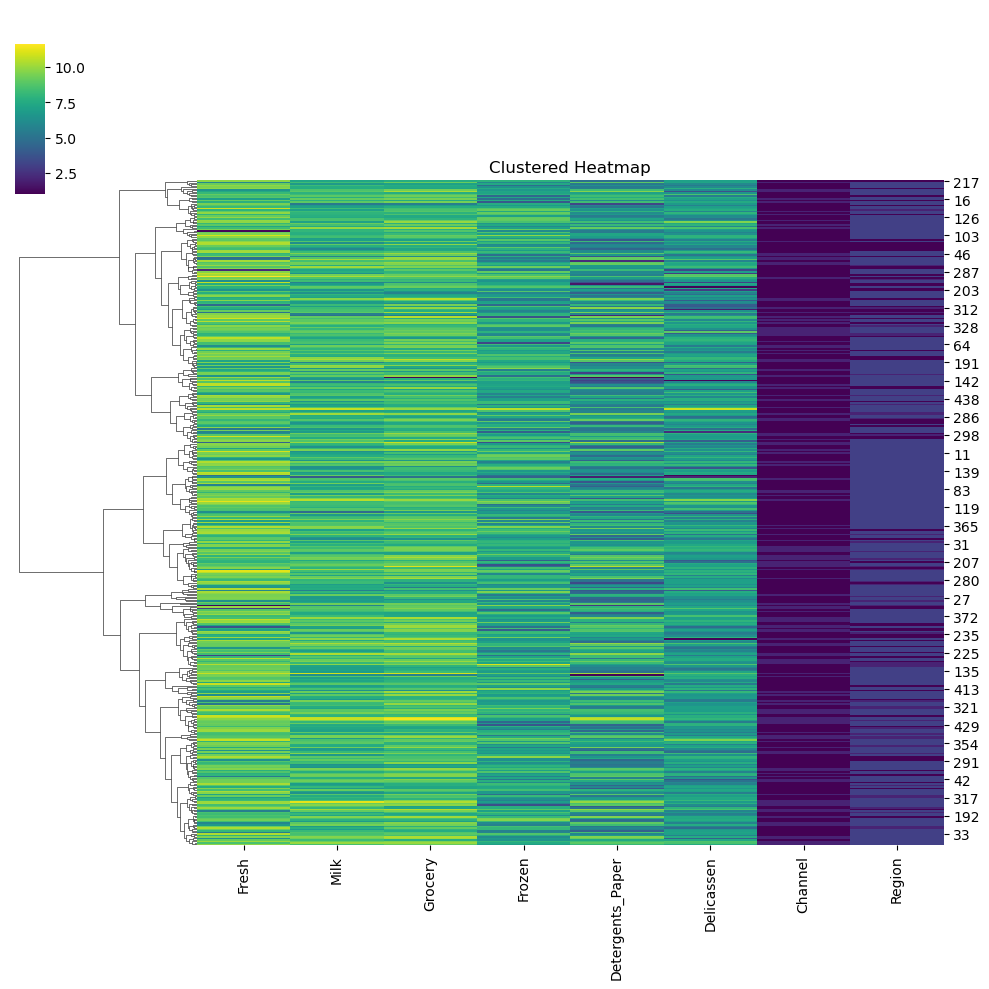

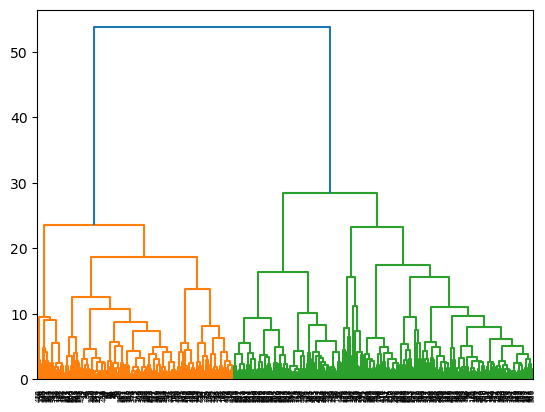

In [9]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import RobustScaler
from imblearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import FunctionTransformer

#Create a transformer based on np.log() function using FunctionTransformer()
log_scaler = FunctionTransformer(func=lambda x: np.log(x), validate = True) 

data = wholesale.copy()
hierclust_pipe = Pipeline([
    ('LogScaler', make_column_transformer((log_scaler, num_feats), remainder='passthrough')),
    ('HierachichalClustering', AgglomerativeClustering(n_clusters = 2, compute_distances = True))
])
hierclust_pipe.fit(data)
labels = hierclust_pipe.named_steps['HierachichalClustering'].labels_

data['Group'] = labels
print(data)
print()

data_scaled_plot = hierclust_pipe.named_steps['LogScaler'].transform(data.iloc[:,:-1])
data_scaled_plot = pd.DataFrame(data_scaled_plot, columns = num_feats + ['Channel', 'Region'])
print('-----------------------------------------------------------------------')
print('Data scaled for plot:\n', data_scaled_plot)
plot_clustered_heatmap(data_scaled_plot, hierclust_pipe.named_steps['HierachichalClustering'])
plot_dendrogram(hierclust_pipe.named_steps['HierachichalClustering'])

# <span style = 'color:yellow'> Report clustering results:

In [10]:
data_group = data.copy()

for group in data_group['Group'].unique():
    print(f'\n=============== Cluster group {group} =========================\n')
    data = data_group[data_group['Group'] == group]
    print(f'n_observations: {data.shape[0]}\n')
    for col_name in data.columns[:-1]:
        if col_name in ['Region', 'Channel']:
            print(f'{data[col_name].value_counts().to_frame().reset_index()}')
            print()
        else:
            print(f'{col_name}: {np.min(data[col_name])} ~ {np.median(data[col_name])} ~ {np.max(data[col_name])}')
            print()


=============== Cluster group 1 =========================

n_observations: 174

   Channel  count
0        2    134
1        1     40

   Region  count
0       3    131
1       1     25
2       2     18

Fresh: 9 ~ 5540.5 ~ 44466

Milk: 577 ~ 7146.0 ~ 73498

Grocery: 572 ~ 11172.5 ~ 92780

Frozen: 25 ~ 952.5 ~ 7782

Detergents_Paper: 516 ~ 4643.5 ~ 40827

Delicassen: 27 ~ 1215.0 ~ 7844


=============== Cluster group 0 =========================

n_observations: 266

   Channel  count
0        1    258
1        2      8

   Region  count
0       3    185
1       1     52
2       2     29

Fresh: 3 ~ 10511.0 ~ 112151

Milk: 55 ~ 1991.5 ~ 43950

Grocery: 3 ~ 2505.5 ~ 28986

Frozen: 47 ~ 2382.0 ~ 60869

Detergents_Paper: 3 ~ 327.5 ~ 4948

Delicassen: 3 ~ 834.0 ~ 47943




=============== Feature name: Channel =========================



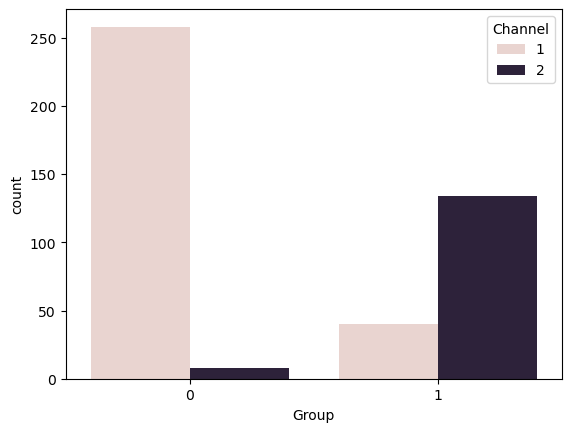


=============== Feature name: Region =========================



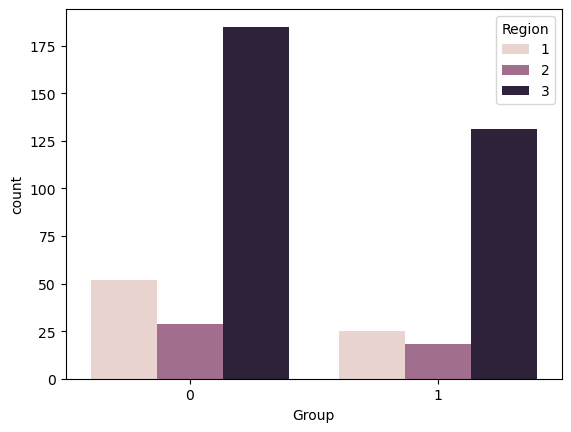


=============== Feature name: Fresh =========================



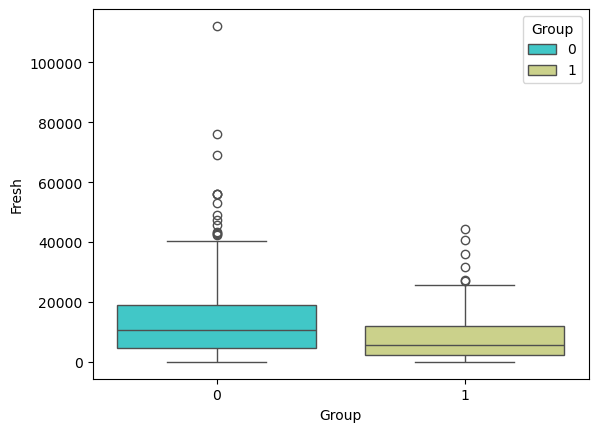


=============== Feature name: Milk =========================



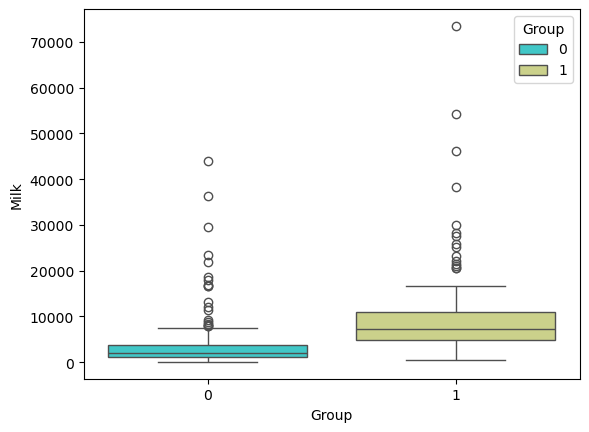


=============== Feature name: Grocery =========================



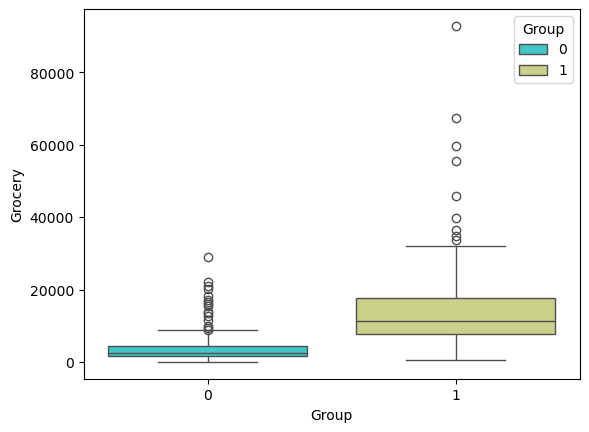


=============== Feature name: Frozen =========================



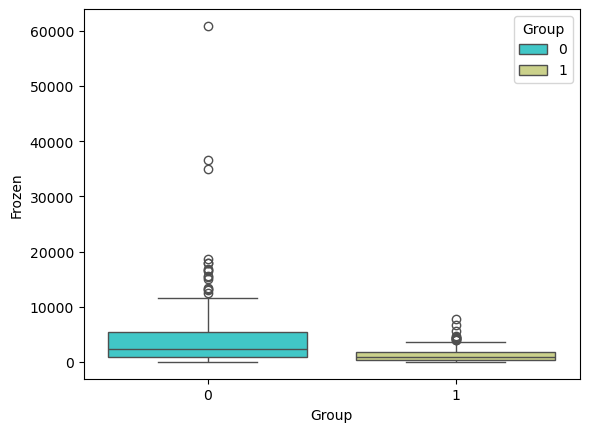


=============== Feature name: Detergents_Paper =========================



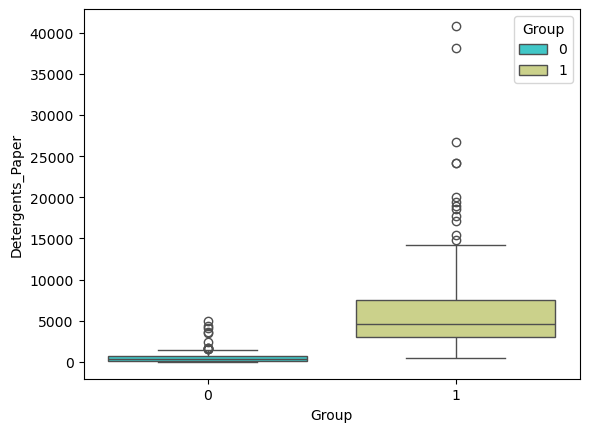


=============== Feature name: Delicassen =========================



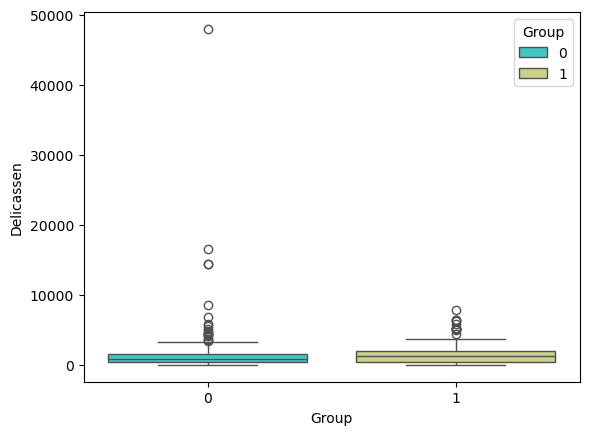

In [11]:
for col_name in data_group.columns[:-1]:
    print(f'\n=============== Feature name: {col_name} =========================\n')
    if col_name in ['Region', 'Channel']:
        sbn.countplot(data = data_group, x = 'Group', hue = col_name)
        plt.show()
    else:
        sbn.boxplot(data = data_group, x = 'Group', y = col_name, hue = 'Group', palette = 'rainbow')
        plt.show()